--- Auditoria: Modelo Predictivo (Random Forest) ---
Accuracy (Exactitud): 0.7533
F1 Score (Weighted):  0.7281
ROC-AUC (OvR):        0.9026



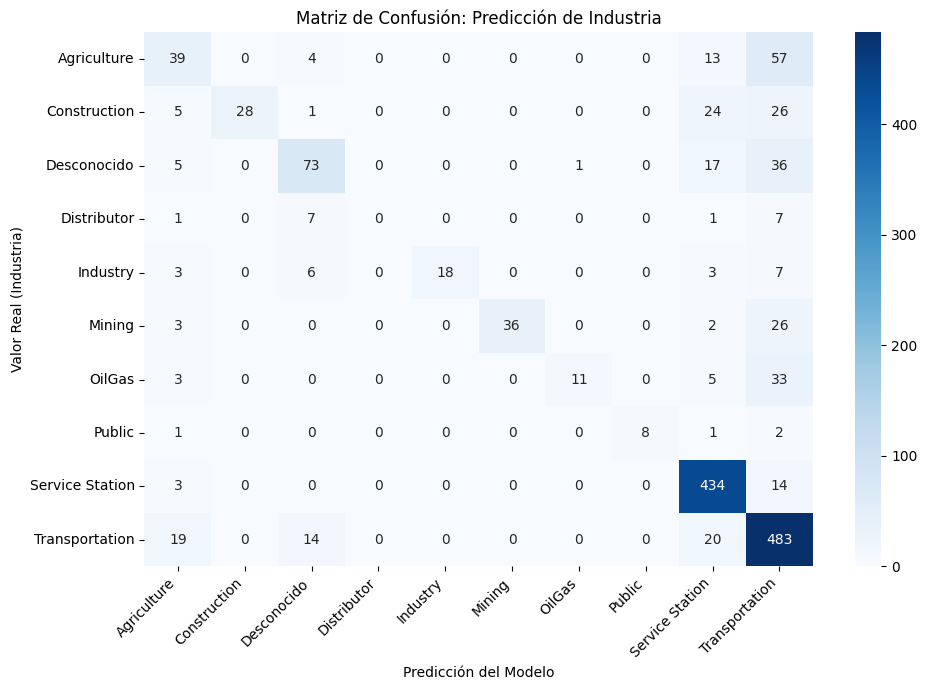

In [14]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# =====================================================================
# 1. EVALUACIÓN DEL MODELO SUPERVISADO
# =====================================================================
y_pred = clf_base.predict(X_test)
y_prob = clf_base.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
cm = confusion_matrix(y_test, y_pred) # <-- Calculamos la matriz aquí

print("--- Auditoria: Modelo Predictivo (Random Forest) ---")
print(f"Accuracy (Exactitud): {accuracy:.4f}")
print(f"F1 Score (Weighted):  {f1:.4f}")
print(f"ROC-AUC (OvR):        {roc_auc:.4f}\n")
# =====================================================================
plt.figure(figsize=(10, 7)) # Tamaño un poco más grande por si hay muchas industrias

# Usamos las clases del modelo para ponerle nombre a las filas y columnas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf_base.classes_,
            yticklabels=clf_base.classes_)

plt.title('Matriz de Confusión: Predicción de Industria')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Industria)')
plt.xticks(rotation=45, ha='right') # Rotamos para que los textos no se pisen
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, silhouette_score
from sklearn.cluster import KMeans # <-- Faltaba importar KMeans
# =====================================================================
# 2. EVALUACIÓN DEL MODELO NO SUPERVISADO
# =====================================================================

kmeans_eval = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_eval = kmeans_eval.fit_predict(X_real_scaled)

sil_score = silhouette_score(X_real_scaled, labels_eval)


print("--- Auditoria: Clustering de Comportamiento (K-Means) ---")
print(f"Silhouette Score:     {sil_score:.4f}")

--- Auditoria: Clustering de Comportamiento (K-Means) ---
Silhouette Score:     0.2126
